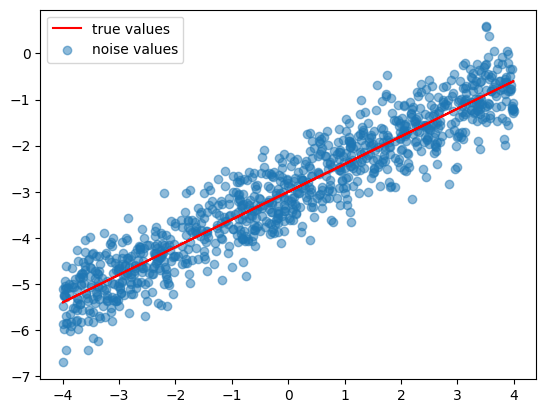

In [32]:
import numpy as np
import matplotlib.pyplot as plt

n_datapoints = 1000
beta0 = -3
beta1 = 0.6

noise_std = 0.5
noise_var = noise_std ** 2

lower_bound = -4
upper_bound = 4

x_vals = np.random.uniform(lower_bound, upper_bound, n_datapoints)
y_vals = beta1 * x_vals + beta0
y_vals_noise = beta1 * x_vals + beta0 + np.random.normal(0, noise_std, n_datapoints)

fig, ax = plt.subplots()
ax.plot(x_vals, y_vals, color='r', label='true values')
ax.scatter(x_vals, y_vals_noise, alpha=0.5, label='noise values')

plt.legend()
plt.show()

In [46]:
from scipy.stats import multivariate_normal

def plot_posterior(mean, cov): 
    posterior = multivariate_normal(mean, np.diag(np.diag(cov)))
    
    mesh_xs, mesh_ys = np.mgrid[lower_bound : upper_bound : 0.1, lower_bound : upper_bound : 0.1]
    pos = np.dstack([mesh_xs, mesh_ys])
    
    pds = posterior.pdf(pos)
    
    fig, ax = plt.subplots()
    ax.contourf(mesh_xs, mesh_ys, pds)
    ax.scatter(beta0, beta1, color='r')

    plt.show()

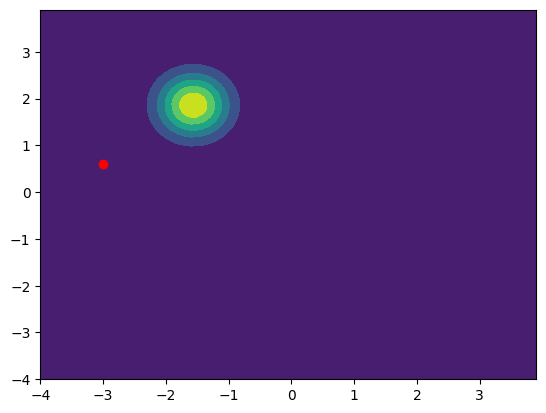

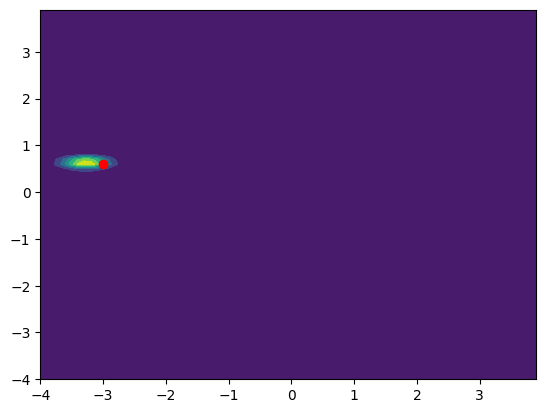

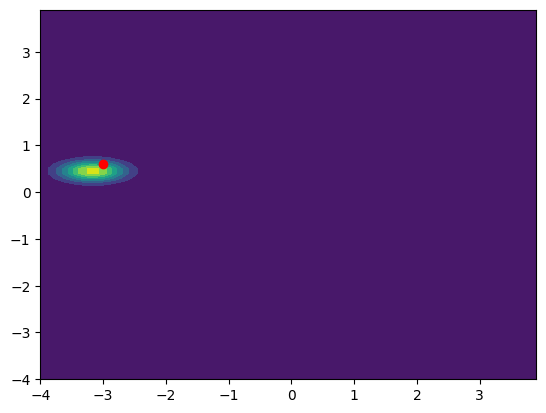

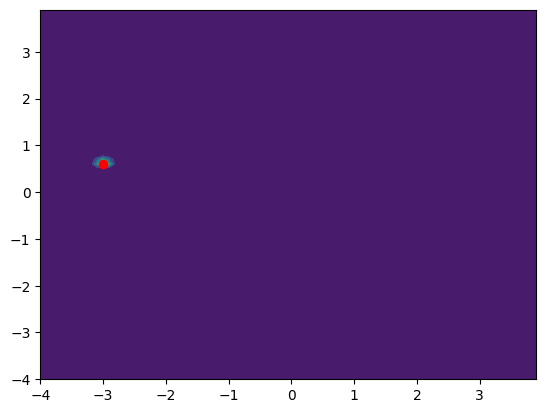

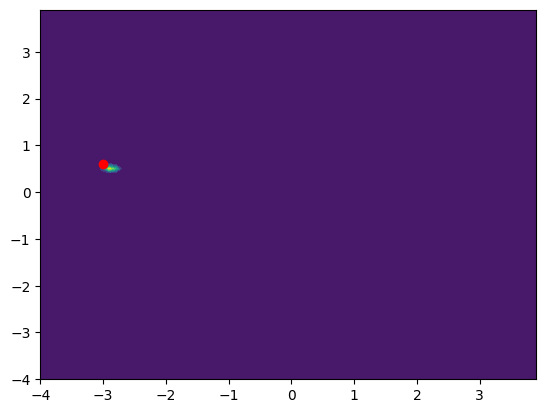

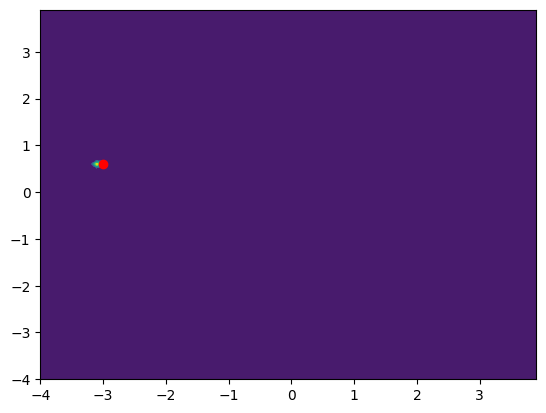

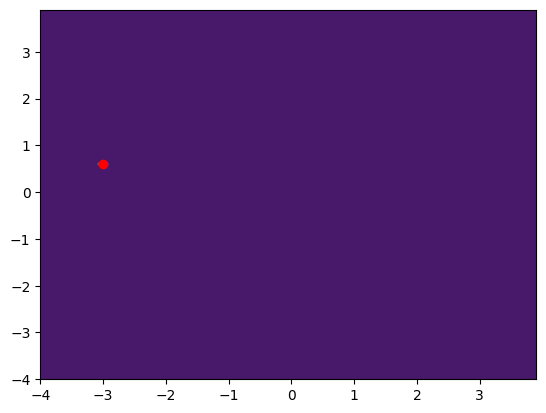

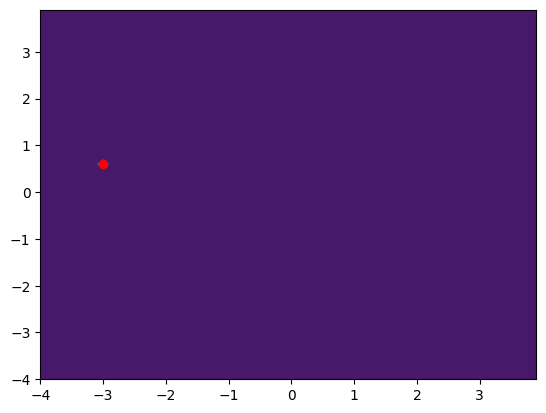

In [47]:
from sklearn.linear_model import BayesianRidge

model = BayesianRidge(max_iter=1000, tol=1e-4, fit_intercept=False)

n_points_lst = [1, 5, 10, 50, 100, 200, 500, 1000]
prev_n_points = 0

for n_points in n_points_lst:
    x_train = x_vals[prev_n_points:n_points]
    y_train = y_vals_noise[prev_n_points:n_points]

    ones = np.ones(len(x_train))
    X_train = np.column_stack([ones, x_train])

    model.fit(X_train, y_train)

    prev_n_points = n_points

    # print(f'n_points {n_points}, mean {model.coef_}, var matrix: {model.sigma_}')
    plot_posterior(model.coef_, model.sigma_)